# Özel Dönüştürücü

In [1]:
import pandas as pd
import seaborn as sns

👉 Bu veri setini kullanacağız:

In [2]:
data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_data.csv")
data.head()

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,days_until_delivery
0,RJ,SP,1825,53,10,40,9
1,RJ,SP,700,65,18,28,9
2,RJ,SP,1825,53,10,40,11
3,RJ,SP,1825,53,10,40,12
4,RJ,SP,1825,53,10,40,14


- Veri setindeki her gözlem, bir `seller_state`'den `customer_state`'e teslim edilen bir öğeyi temsil eder. 
- Diğer sütunlar her öğenin ambalaj özelliklerini tanımlar.

🎯 Hedef, sipariş ile teslimat arasındaki gün sayısıdır.

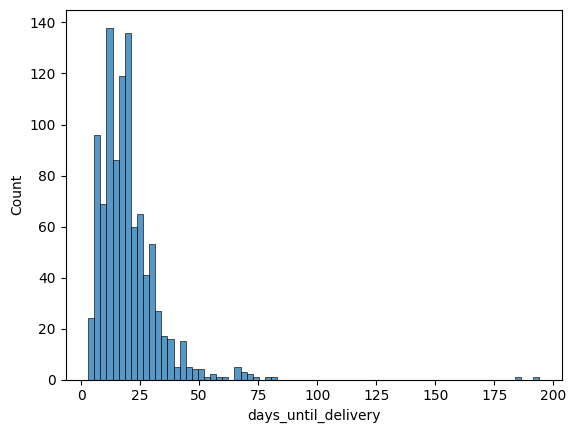

In [3]:
# Check target
sns.histplot(data.days_until_delivery);

## 1. İşlem Hattı

👉 `pipe` adında bir scikit-learn işlem hattı oluşturun:

- Boyut özelliklerinden bir `volume` özelliği mühendisliği yapın
- Orijinal ürün boyutları özelliklerini eğitim için saklayın
- Tüm sayısal özellikleri ölçeklendirin
- Kategorik özellikleri kodlayın
- Varsayılan bir `Ridge` regresyon tahmincisi ekleyin

**Not:** Bu challenge için holdout yöntemini göz ardı edin, dolayısıyla `train_test_split` gerekmez!

<details><summary><strong>İpuçları</strong></summary>

- Ön işlenmiş matrisinizi oluşturmanın birçok yolu vardır (`ColumnTransformer` ve/veya `FeatureUnion` kullanarak). 
    
- Dönüştürülmüş özellik matrisiniz garip görünüyorsa, `OneHotEncoder(sparse_output=True)`'nun varsayılan davranışı nedeniyle "seyrek" olarak saklanıyor olabilir. Yoğun bir matrise geri döndürmek için `.todense()` kullanın.

- Varsayılan NumPy dizisi yerine sütun adları içeren bir Pandas DataFrame çıktısı almak için final işlem hattınızda `.set_output(transform='pandas')` kullanın. (Her bir dönüştürücüde ayrı ayrı ayarlamanıza gerek yok. İşlem hattında ayarlarsanız, alt aşamalara iletir.)

</details>

<br>

<details><summary><strong>Daha fazla ipucu: adım adım rehber</strong> (sadece takılıp kaldığınızda açın)</summary>

İşlem hattınızı oluşturmanın en kolay yolu budur.

1. Uzunluk, genişlik ve yükseklik verilen hacmi hesaplamak için bir python fonksiyonu oluşturun.
1. Şunlardan oluşan bir hacim hesaplayıcı işlem hattı oluşturun:
   1. Python fonksiyonunuzu kullanan bir `FunctionTransformer`.
   1. Ardından bir ölçekleyici
1. Şunları içeren `ColumnTransformer` kullanarak tam ön işleyiciyi oluşturun:
   - Orijinal sayısal fonksiyonlar için bir ölçekleyici.
   - Kategorik fonksiyonlar için bir kodlayıcı.
   - Uzunluk, genişlik ve yükseklik özellikleri için hacim hesaplayıcı işlem hattınız.
1. Son olarak, tam ön işleyicinizin ardından `Ridge` modelinin geldiği bir işlem hattı yapın.

</details>

In [ ]:
# YOUR CODE HERE

### Çözümler

#### Ön İşleme Çözümü 1: Fonksiyon Dönüştürücü

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.base import TransformerMixin
from sklearn.base import BaseEstimator

from sklearn.pipeline import FeatureUnion

In [7]:
X = data.drop(columns=['days_until_delivery'])
y = data['days_until_delivery']
X.head()

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,RJ,SP,1825,53,10,40
1,RJ,SP,700,65,18,28
2,RJ,SP,1825,53,10,40
3,RJ,SP,1825,53,10,40
4,RJ,SP,1825,53,10,40


In [12]:
def multiply(data):
    return pd.DataFrame(
        data["product_length_cm"] * data["product_height_cm"] * data["product_width_cm"]
    )


volume_computer = Pipeline(
    [
        ("compute_volume", FunctionTransformer(multiply)),
        ("scale_volume", MinMaxScaler()),
    ]
)

final_preprocessor = ColumnTransformer(
    [
        (
            "num_scaler",
            MinMaxScaler(),
            make_column_selector(dtype_include="int64"),
        ),
        (
            "cat_encoder",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=False, drop="if_binary"
            ),
            make_column_selector(dtype_include="object"),
        ),
        (
            "volume_computer",
            volume_computer,
            ["product_length_cm", "product_height_cm", "product_width_cm"],
        ),
    ]
).set_output(transform="pandas")

final_preprocessor

ColumnTransformer(transformers=[('num_scaler', MinMaxScaler(),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7353b63f8f50>),
                                ('cat_encoder',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7353b63f9730>),
                                ('volume_computer',
                                 Pipeline(steps=[('compute_volume',
                                                  FunctionTransformer(func=<function multiply at 0x7353b642bd80>)),
                                                 ('scale_volume',
                                                  MinMaxScaler())]),
                                 ['product_length_cm', 'product_height_cm',
                                  'product_width_cm'])])

In [16]:
df = final_preprocessor.fit_transform(X)
df.shape

(1000, 31)

In [ ]:
preprocessor = ColumnTransformer(
    [
        (
            "num_scaler",
            MinMaxScaler(),
            make_column_selector(dtype_include="int64"),
        ),
        (
            "cat_encoder",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=False, drop="if_binary"
            ),
            make_column_selector(dtype_include="object"),
        ),
    ]
)


def multiply(df):
    return pd.DataFrame(
        df["product_length_cm"] * df["product_height_cm"] * df["product_width_cm"]
    )


volume_computer = Pipeline(
    [
        (
            "compute_volume",
            FunctionTransformer(multiply),
        ),
        ("scale_volume", MinMaxScaler()),
    ]
)

final_preprocessor2 = FeatureUnion(
    [("preprocesses", preprocessor), ("compute_volume", volume_computer)]
).set_output(transform="pandas")

final_preprocessor2

In [ ]:
final_preprocessor2.fit_transform(X)

#### Ön İşleme Çözümü 2: Özel dönüştürücü sınıfı (gereksiz karmaşıklık)

In [ ]:
# Create a class
class ColumnMultiplier(TransformerMixin, BaseEstimator):
    """
    Compute the product (volume) of three specified DataFrame columns.

    Parameters
    ----------
    column_1 : str
        Name of the first column to multiply (e.g. length).
    column_2 : str
        Name of the second column to multiply (e.g. height).
    column_3 : str
        Name of the third column to multiply (e.g. width).

    Behavior
    --------
    - fit is a no-op to satisfy scikit-learn transformer API.
    - transform returns a pandas.DataFrame with a single column 'volume'
      containing the element-wise product of the three specified columns.
    - Designed to integrate into ColumnTransformer / Pipeline workflows.

    Returns
    -------
    pandas.DataFrame
        DataFrame with shape (n_samples, 1) and column name 'volume'.

    Inherits from:
    - TransformerMixin: generates a fit_transform method from fit and transform
    - BaseEstimator: generates get_params and set_params methods
    """

    # Create parameters "column_1", "column_2", "column_3" to choose which columns of dataframe to multiply
    def __init__(self, column_1, column_2, column_3):
        self.column_1 = column_1
        self.column_2 = column_2
        self.column_3 = column_3

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        # Multiplication
        multiplied_features = X[self.column_1] * X[self.column_2] * X[self.column_3]

        # Return result as dataframe (for integration into ColumnTransformer)
        return pd.DataFrame(multiplied_features, columns=["volume"])

    def get_feature_names_out(self):
        return self.multiplied_features.columns

In [ ]:
# Plug custom transformer into a feature engineering ColumnTransformer
# Select and preserve the original features
feature_engineering = ColumnTransformer(
    [
        (  # ColumnMultiplier BEGIN
            "column_multiplier",
            ColumnMultiplier(
                column_1="product_length_cm",
                column_2="product_height_cm",
                column_3="product_width_cm",
            ),
            ["product_length_cm", "product_height_cm", "product_width_cm"],
        ),  # ColumnMultiplier END
        (  # FunctionTransformer BEGIN
            "select_original_features",
            FunctionTransformer(lambda x: x),
            [
                "product_length_cm",
                "product_height_cm",
                "product_width_cm",
                "product_weight_g",
            ],
        ),  # FunctionTransformer END
    ]
)

# Chain the feature engineering transformer with a scaler
numerical_pipe = Pipeline(
    [("engineering", feature_engineering), ("scaling", MinMaxScaler())]
)

# Create a final preprocessing pipeline that combines the above pipeline with a One hot encoder for categorical features
final_preprocessor3 = ColumnTransformer(
    [
        (
            "categorical_preprocessing",
            OneHotEncoder(
                sparse_output=False, handle_unknown="ignore", drop="if_binary"
            ),
            make_column_selector(dtype_include="object"),
        ),
        (
            "numerical_preprocessing",
            numerical_pipe,
            make_column_selector(dtype_include="int64"),
        ),
    ]
).set_output(transform="pandas")

In [ ]:
final_preprocessor3

In [ ]:
final_preprocessor3.fit_transform(X)

In [ ]:
final_preprocessor3.fit_transform(X).shape

#### Tam İşlem Hattı çözümü

In [13]:
from sklearn.linear_model import Ridge

# Chain the final_preprocessor pipeline with a linear regression model
pipe = Pipeline([
    ('preprocessing', final_preprocessor),
    ('linear_regression', Ridge())
])

pipe

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_scaler', MinMaxScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7353b63f8f50>),
                                                 ('cat_encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7353b63f9730>),
                                                 ('volume_computer',
                                                  Pipeline(steps=[('compute_volume',
                                                                   FunctionTransformer(func=<function multiply at 0x7353b642bd80>)),
                                                                  ('scale_volume',
                                                                   MinMaxScaler())]),
                                                  ['product_length_cm',
                                                   'product_height_cm',
                                                   'product_width_cm'])])),
                ('linear_regression', Ridge())])

#### 🧪 İşlem hattınızı test edin

In [14]:
from nbresult import ChallengeResult

pipe_test = pipe

# Check that it doesn't crash
assert pipe_test.fit(X, y)

result = ChallengeResult(
    'pipe',
    shape = pipe_test[:-1].fit_transform(X).shape
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/mert/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/mert/Sprint-17/S17D1-S-Data-Custom-Transformer/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_pipe.py::TestPipe::test_pipe_not_crashing PASSED                    [100%]

============================== 1 passed in 0.57s ===============================


💯 You can commit your code:

git add tests/pipe.pickle

git commit -m 'Completed pipe step'

git push origin master



## 2. Eğit ve Tahmin Et

👇 `data`'nın tüm eğitim setiniz olduğunu hayal edelim.

- Bu veri setinde işlem hattınızı `cross_validate` edin (❗️düşük $R_2$ skorları beklenir)
- Şimdi, yeni bir sipariş `new_data` aldığınızı hayal edin: teslimat süresini `prediction` değişkeninde tahmin edin

In [ ]:
new_data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_new_order.csv")
new_data

In [ ]:
# YOUR CODE HERE

In [ ]:
from sklearn.model_selection import cross_val_score

# Cross validate the final_pipe
cross_val_score(pipe, X, y, cv=10, scoring='r2').mean()

0.15838731743600062

In [ ]:
# Fit the final pipe to the data
pipe.fit(X, y)

In [ ]:
# Use final pipe for prediction
prediction = pipe.predict(new_data)
prediction

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'prediction',
    prediction = prediction
)

result.write()
print(result.check())


🏁 Tebrikler. Notebook'unuzu eklemeyi, commit etmeyi ve push etmeyi unutmayın.